EMPLOYEE ATTRITION PREDICTION
MACHINE LEARNING MODEL DEVELOPMENT

Dataset loaded successfully.
Dataset shape: (1470, 35)

Feature shape: (1470, 34)
Target shape: (1470,)

Irrelevant columns removed.
Remaining features: 30

Training data: (1102, 30)
Testing data: (368, 30)

Numerical features: 23
Categorical features: 7

Preprocessing pipeline created.

Logistic Regression
Accuracy : 0.8668
Precision: 0.6562
Recall   : 0.3559
F1 Score : 0.4615
ROC-AUC  : 0.8137

Decision Tree
Accuracy : 0.7446
Precision: 0.2222
Recall   : 0.2373
F1 Score : 0.2295
ROC-AUC  : 0.5394

Random Forest
Accuracy : 0.8533
Precision: 0.6667
Recall   : 0.1695
F1 Score : 0.2703
ROC-AUC  : 0.7946


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.867,0.656,0.356,0.462,0.814
2,Random Forest,0.853,0.667,0.169,0.270,0.795
1,Decision Tree,0.745,0.222,0.237,0.230,0.539


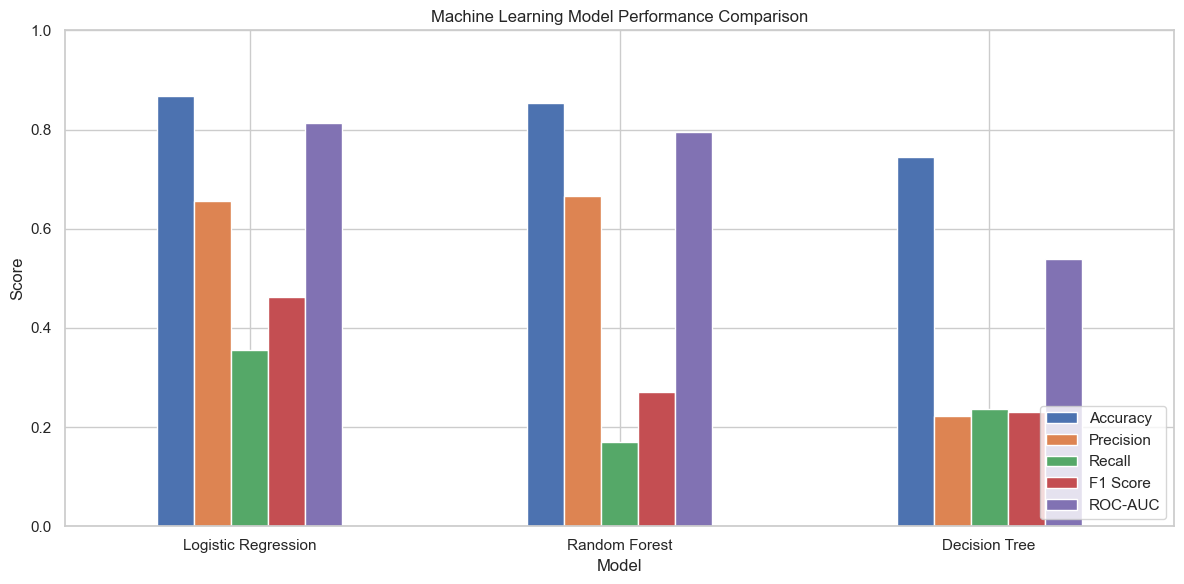


Best baseline model:
Logistic Regression


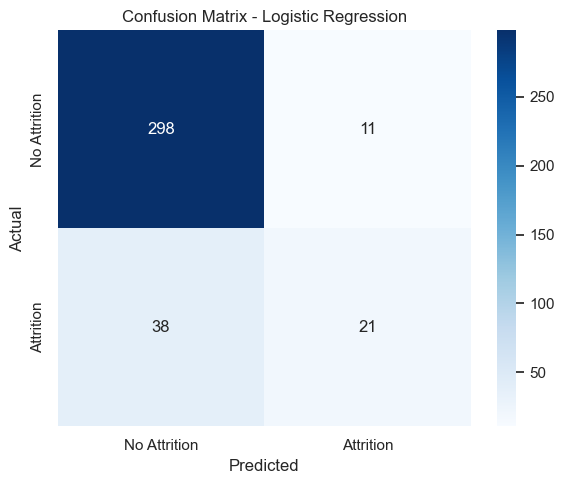


Classification Report:
              precision    recall  f1-score   support

No Attrition       0.89      0.96      0.92       309
   Attrition       0.66      0.36      0.46        59

    accuracy                           0.87       368
   macro avg       0.77      0.66      0.69       368
weighted avg       0.85      0.87      0.85       368



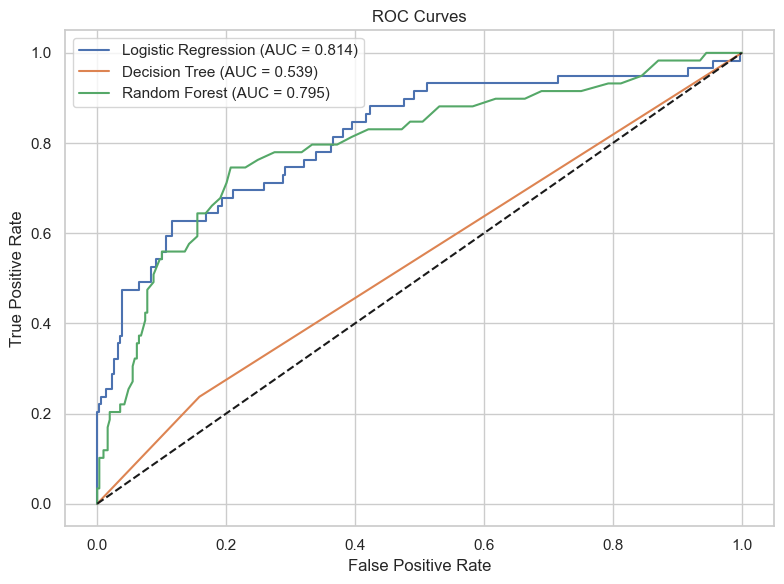



MODEL IMPROVEMENT

The dataset has an imbalanced target variable.
Attrition = Yes represents a smaller portion of the dataset.

To improve detection of employees likely to leave,
class_weight='balanced' is used.


Improved Random Forest Results:


,Metric,Improved Model
0,Accuracy,0.848
1,Precision,0.588
2,Recall,0.169
3,F1 Score,0.263
4,ROC-AUC,0.781



Baseline vs Improved Model:


,Metric,Baseline Random Forest,Improved Random Forest
0,Accuracy,0.853,0.848
1,Precision,0.667,0.588
2,Recall,0.169,0.169
3,F1 Score,0.270,0.263
4,ROC-AUC,0.795,0.781



Final model saved successfully:
../models/final_model.pkl


MODEL DEVELOPMENT COMPLETED

Models implemented:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Model evaluation:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

Model improvement:
- Class imbalance handling using class_weight='balanced'
- Random Forest parameter improvement

Final model saved for deployment.



In [3]:
# ============================================================
# EMPLOYEE ATTRITION PREDICTION
# MACHINE LEARNING MODEL DEVELOPMENT
# MODEL EVALUATION + MODEL IMPROVEMENT
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set_theme(style="whitegrid")

print("=" * 70)
print("EMPLOYEE ATTRITION PREDICTION")
print("MACHINE LEARNING MODEL DEVELOPMENT")
print("=" * 70)


# ============================================================
# 2. LOAD DATASET
# ============================================================

data_path = "../data/WA_Fn-UseC_-HR-Employee-Attrition.csv"

df = pd.read_csv(data_path)

print("\nDataset loaded successfully.")
print("Dataset shape:", df.shape)


# ============================================================
# 3. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["Attrition"])

y = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 4. REMOVE IRRELEVANT COLUMNS
# ============================================================

columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

X = X.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("\nIrrelevant columns removed.")
print("Remaining features:", X.shape[1])


# ============================================================
# 5. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


# ============================================================
# 6. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("\nNumerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


# ============================================================
# 7. CREATE PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("\nPreprocessing pipeline created.")


# ============================================================
# 8. DEFINE MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}


# ============================================================
# 9. TRAIN MODELS AND EVALUATE
# ============================================================

results = []

trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # Train model
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = pipeline.predict(X_test)

    y_probability = pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_probability
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[name] = pipeline

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))


# ============================================================
# 10. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n")
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1 Score": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)


# ============================================================
# 11. MODEL COMPARISON VISUALIZATION
# ============================================================

results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()


# ============================================================
# 12. SELECT BEST BASELINE MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_baseline_model = trained_models[
    best_model_name
]

print("\nBest baseline model:")
print(best_model_name)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

y_pred_best = best_baseline_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=[
            "No Attrition",
            "Attrition"
        ],
        zero_division=0
    )
)


# ============================================================
# 15. ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for name, model in trained_models.items():

    probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc_score = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    "k--"
)

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 16. MODEL IMPROVEMENT
# ============================================================

print("\n")
print("=" * 70)
print("MODEL IMPROVEMENT")
print("=" * 70)

print("""
The dataset has an imbalanced target variable.
Attrition = Yes represents a smaller portion of the dataset.

To improve detection of employees likely to leave,
class_weight='balanced' is used.
""")


# ============================================================
# 17. IMPROVED RANDOM FOREST
# ============================================================

improved_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                max_depth=10,
                min_samples_split=5,
                random_state=42
            )
        )
    ]
)

improved_pipeline.fit(
    X_train,
    y_train
)

improved_pred = improved_pipeline.predict(
    X_test
)

improved_probability = (
    improved_pipeline.predict_proba(X_test)[:, 1]
)


# ============================================================
# 18. EVALUATE IMPROVED MODEL
# ============================================================

improved_accuracy = accuracy_score(
    y_test,
    improved_pred
)

improved_precision = precision_score(
    y_test,
    improved_pred,
    zero_division=0
)

improved_recall = recall_score(
    y_test,
    improved_pred,
    zero_division=0
)

improved_f1 = f1_score(
    y_test,
    improved_pred,
    zero_division=0
)

improved_auc = roc_auc_score(
    y_test,
    improved_probability
)

improved_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Improved Model": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1,
        improved_auc
    ]
})

print("\nImproved Random Forest Results:")
display(
    improved_results.style.format({
        "Improved Model": "{:.3f}"
    })
)


# ============================================================
# 19. BEFORE VS AFTER
# ============================================================

baseline_row = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

comparison = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline Random Forest": [
        baseline_row["Accuracy"],
        baseline_row["Precision"],
        baseline_row["Recall"],
        baseline_row["F1 Score"],
        baseline_row["ROC-AUC"]
    ],

    "Improved Random Forest": [
        improved_accuracy,
        improved_precision,
        improved_recall,
        improved_f1,
        improved_auc
    ]
})

print("\nBaseline vs Improved Model:")
display(
    comparison.style.format({
        "Baseline Random Forest": "{:.3f}",
        "Improved Random Forest": "{:.3f}"
    })
)


# ============================================================
# 20. SAVE FINAL MODEL
# ============================================================

os.makedirs("../models", exist_ok=True)

final_model_path = "../models/final_model.pkl"

joblib.dump(
    improved_pipeline,
    final_model_path
)

print("\nFinal model saved successfully:")
print(final_model_path)


# ============================================================
# 21. FINAL MODEL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("MODEL DEVELOPMENT COMPLETED")
print("=" * 70)

print("""
Models implemented:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Model evaluation:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

Model improvement:
- Class imbalance handling using class_weight='balanced'
- Random Forest parameter improvement

Final model saved for deployment.
""")
